# Proyecto Zuber — Análisis de viajes en taxi en Chicago

Zuber es una nueva empresa de viajes compartidos lanzándose en Chicago. El objetivo de este análisis es:
- Entender las preferencias de los pasajeros
- Analizar el impacto del clima en la duración de los viajes
- Probar la hipótesis de que los viajes del Loop al aeropuerto O'Hare duran más los sábados lluviosos

## Paso 4 — Análisis Exploratorio de Datos

### 4.1 Importación de librerías y archivos

Importamos las librerías necesarias y cargamos los dos datasets:
- `project_sql_result_01.csv`: empresas de taxis y número de viajes el 15-16 de noviembre de 2017
- `project_sql_result_04.csv`: barrios de Chicago y promedio de viajes finalizados en noviembre de 2017

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos los datasets
df_companies = pd.read_csv('moved_project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('moved_project_sql_result_04.csv')

### 4.2 Exploración del dataset de empresas de taxis

Revisamos la estructura, tipos de datos y primeras filas del dataset de empresas.

In [3]:
# Información general del dataset
print('=== INFO ===')
print(df_companies.info())
print()
print('=== PRIMERAS FILAS ===')
print(df_companies.head())
print()
print('=== VALORES NULOS ===')
print(df_companies.isnull().sum())
print()
print('=== ESTADÍSTICAS ===')
print(df_companies.describe())

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 2.5 KB
None

=== PRIMERAS FILAS ===
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

=== VALORES NULOS ===
company_name    0
trips_amount    0
dtype: int64

=== ESTADÍSTICAS ===
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000


### 4.3 Exploración del dataset de barrios

Revisamos la estructura, tipos de datos y primeras filas del dataset de barrios.

In [4]:
print('=== INFO ===')
print(df_neighborhoods.info())
print()
print('=== PRIMERAS FILAS ===')
print(df_neighborhoods.head())
print()
print('=== VALORES NULOS ===')
print(df_neighborhoods.isnull().sum())
print()
print('=== ESTADÍSTICAS ===')
print(df_neighborhoods.describe())

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     str    
 1   average_trips          94 non-null     float64
dtypes: float64(1), str(1)
memory usage: 2.6 KB
None

=== PRIMERAS FILAS ===
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

=== VALORES NULOS ===
dropoff_location_name    0
average_trips            0
dtype: int64

=== ESTADÍSTICAS ===
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667


### 4.4 Top 10 barrios por número de finalizaciones

Ordenamos el dataset de barrios de mayor a menor por `average_trips` y tomamos los primeros 10.

In [5]:
# Ordenar y tomar top 10
top_10_neighborhoods = df_neighborhoods.sort_values('average_trips', ascending=False).head(10)

print('=== TOP 10 BARRIOS POR FINALIZACIONES ===')
print(top_10_neighborhoods.to_string(index=False))

=== TOP 10 BARRIOS POR FINALIZACIONES ===
dropoff_location_name  average_trips
                 Loop   10727.466667
          River North    9523.666667
        Streeterville    6664.666667
            West Loop    5163.666667
               O'Hare    2546.900000
            Lake View    2420.966667
           Grant Park    2068.533333
        Museum Campus    1510.000000
           Gold Coast    1364.233333
   Sheffield & DePaul    1259.766667


### 4.5 Gráfico — Empresas de taxis y número de viajes

Visualizamos las empresas de taxis ordenadas por cantidad de viajes el 15-16 de noviembre de 2017.

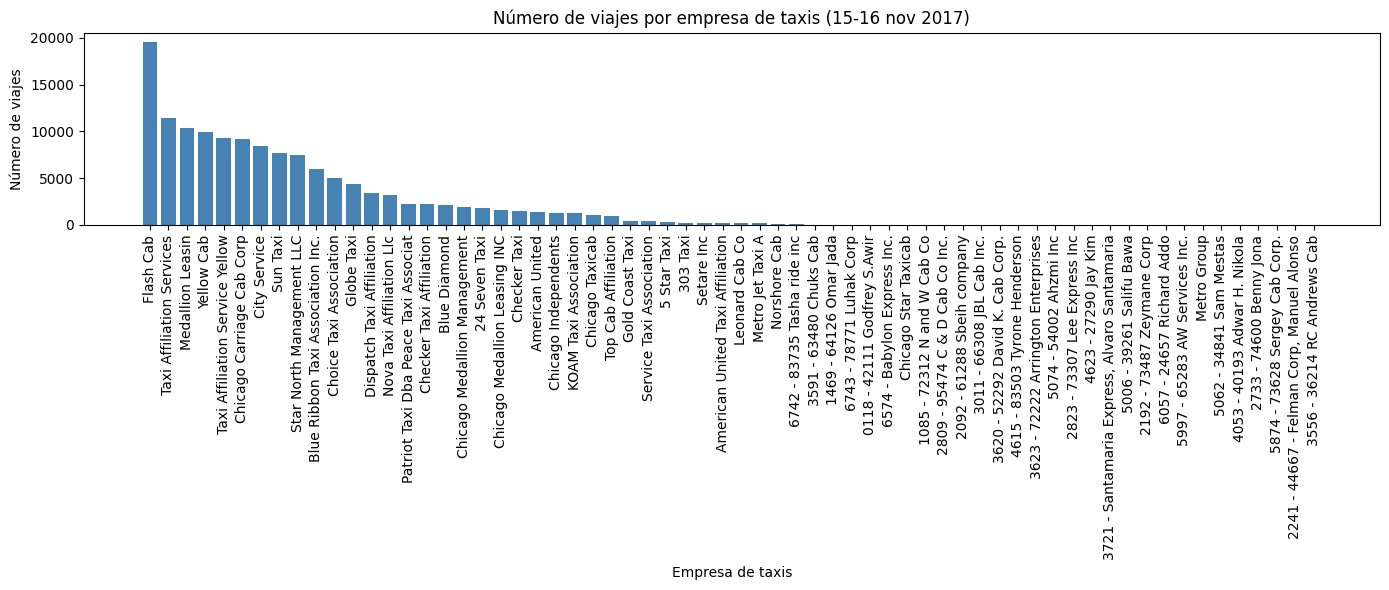

In [6]:
# Ordenar de mayor a menor para el gráfico
df_companies_sorted = df_companies.sort_values('trips_amount', ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(df_companies_sorted['company_name'], df_companies_sorted['trips_amount'], color='steelblue')
plt.xticks(rotation=90)
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes')
plt.title('Número de viajes por empresa de taxis (15-16 nov 2017)')
plt.tight_layout()
plt.show()

**Conclusión:** Flash Cab lidera con una diferencia notable respecto al resto de empresas. Las primeras 3-4 empresas concentran la mayor parte de los viajes, mientras que la mayoría de las empresas tienen volúmenes similares y bajos. Esto indica un mercado con pocos actores dominantes.

### 4.6 Gráfico — Top 10 barrios por número de finalizaciones

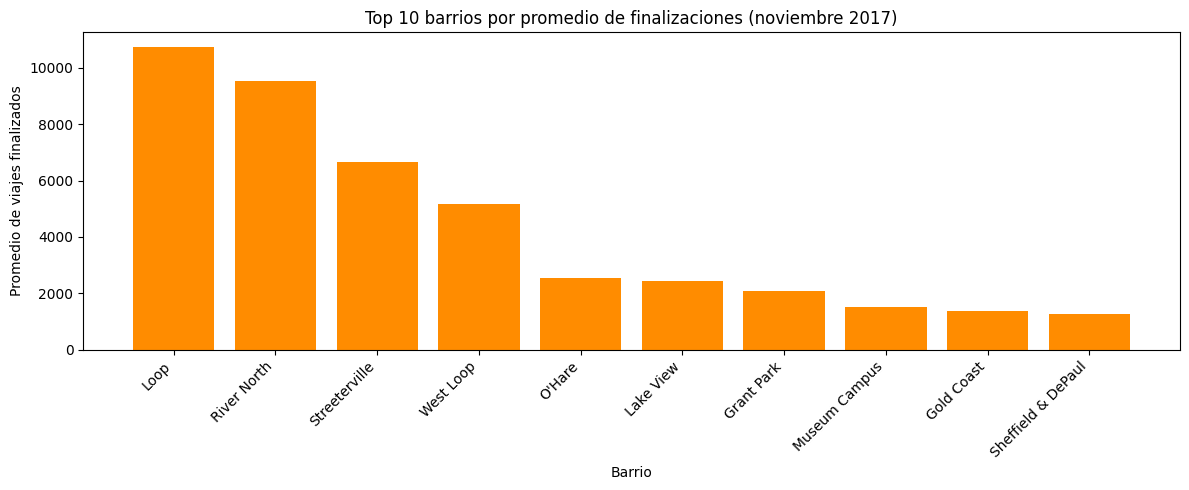

In [7]:
plt.figure(figsize=(12, 5))
plt.bar(top_10_neighborhoods['dropoff_location_name'], top_10_neighborhoods['average_trips'], color='darkorange')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Barrio')
plt.ylabel('Promedio de viajes finalizados')
plt.title('Top 10 barrios por promedio de finalizaciones (noviembre 2017)')
plt.tight_layout()
plt.show()

**Conclusión:** Loop y River North son los barrios con mayor cantidad de viajes finalizados, lo que tiene sentido ya que son zonas céntricas y comerciales de Chicago. O'Hare aparece en el top 5, confirmando que el aeropuerto es un destino frecuente. Hay una caída pronunciada después de los primeros 2-3 barrios.

---
## Paso 5 — Prueba de Hipótesis

### 5.1 Carga y exploración del dataset

Cargamos el dataset con los viajes del Loop al aeropuerto O'Hare los sábados de noviembre de 2017.

In [8]:
from scipy import stats

df_trips = pd.read_csv('moved_project_sql_result_07.csv')

# Convertir start_ts a tipo datetime
df_trips['start_ts'] = pd.to_datetime(df_trips['start_ts'])

print('=== INFO ===')
print(df_trips.info())
print()
print('=== PRIMERAS FILAS ===')
print(df_trips.head())
print()
print('=== DISTRIBUCIÓN DE CONDICIONES CLIMÁTICAS ===')
print(df_trips['weather_conditions'].value_counts())
print()
print('=== ESTADÍSTICAS DE DURACIÓN ===')
print(df_trips.groupby('weather_conditions')['duration_seconds'].describe())

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[us]
 1   weather_conditions  1068 non-null   str           
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 29.2 KB
None

=== PRIMERAS FILAS ===
             start_ts weather_conditions  duration_seconds
0 2017-11-25 16:00:00               Good            2410.0
1 2017-11-25 14:00:00               Good            1920.0
2 2017-11-25 12:00:00               Good            1543.0
3 2017-11-04 10:00:00               Good            2512.0
4 2017-11-11 07:00:00               Good            1440.0

=== DISTRIBUCIÓN DE CONDICIONES CLIMÁTICAS ===
weather_conditions
Good    888
Bad     180
Name: count, dtype: int64

=== ESTADÍSTICAS DE DURACIÓN ===
          

### 5.2 Planteamiento de la hipótesis

Queremos probar si el clima afecta la duración de los viajes los sábados.

- **Hipótesis nula (H0):** La duración promedio de los viajes con clima Bad es **igual** a la duración promedio con clima Good. El clima no tiene efecto.
- **Hipótesis alternativa (H1):** La duración promedio de los viajes con clima Bad es **diferente** a la duración promedio con clima Good. El clima sí tiene efecto.

Usaremos la **prueba t de Student para muestras independientes** (`ttest_ind`) porque:
- Tenemos dos grupos independientes: viajes con clima Bad y viajes con clima Good
- Queremos comparar sus medias
- Es la prueba estándar para este tipo de comparación

El nivel de significación elegido es **alfa = 0.05** (5%), que es el estándar en análisis estadístico.

In [9]:
# Separar los dos grupos
bad_weather = df_trips[df_trips['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = df_trips[df_trips['weather_conditions'] == 'Good']['duration_seconds']

print(f'Viajes con clima Bad:  {len(bad_weather)} viajes, duración promedio: {bad_weather.mean():.0f} segundos')
print(f'Viajes con clima Good: {len(good_weather)} viajes, duración promedio: {good_weather.mean():.0f} segundos')

# Prueba t de Student
alpha = 0.05
results = stats.ttest_ind(bad_weather, good_weather)

print(f'\nResultado de la prueba t:')
print(f'  Estadístico t: {results.statistic:.4f}')
print(f'  p-valor:       {results.pvalue:.4f}')
print(f'  alfa:          {alpha}')
print()

if results.pvalue < alpha:
    print('Conclusión: RECHAZAMOS H0 — El clima SÍ afecta la duración de los viajes.')
else:
    print('Conclusión: NO RECHAZAMOS H0 — No hay evidencia suficiente de que el clima afecte la duración.')

Viajes con clima Bad:  180 viajes, duración promedio: 2427 segundos
Viajes con clima Good: 888 viajes, duración promedio: 2000 segundos

Resultado de la prueba t:
  Estadístico t: 6.9462
  p-valor:       0.0000
  alfa:          0.05

Conclusión: RECHAZAMOS H0 — El clima SÍ afecta la duración de los viajes.


### 5.3 Conclusión final

*(Completa esta celda después de ver el resultado)*

Si **p-valor < 0.05**: Hay evidencia estadística de que los viajes duran más cuando el clima es malo (lluvia o tormenta). Esto tiene sentido porque el mal clima ralentiza el tráfico en Chicago.

Si **p-valor >= 0.05**: No hay evidencia suficiente para afirmar que el clima cambia la duración de los viajes los sábados, al menos con los datos disponibles.